# PROYECTO INTEGRADOR: Predicción de Fuga de Clientes (Customer Churn)
## Cuaderno 01: Análisis Exploratorio de Datos (EDA) Orientado a Preguntas de Negocio

**Curso:** Data Mining Tools (CC209) — UPC  
**Fase:** Trabajo Parcial (TP1) — Semana 7  
**Docente:** Carlos Fernando Montoya Cubas  

---

### 1. Contexto del problema y preguntas de investigación

El proyecto analiza la fuga de clientes utilizando el dataset **Telco Customer Churn**. En esta muestra, el objetivo es comprender qué características contractuales, de servicio y facturación están asociadas con `Churn`, para orientar el modelamiento posterior.

Este análisis exploratorio busca responder cuatro preguntas concretas:

1. **¿Qué tipo de compromiso contractual presenta mayor tasa observada de fuga?**
2. **¿Existe una concentración de churn durante los primeros meses de antigüedad?**
3. **¿Cómo se relacionan los cargos mensuales y el soporte técnico con la tasa observada de churn?**
4. **¿Existen problemas de calidad, tipado, categorías o valores atípicos que condicionen el preprocesamiento?**

> **Principio de interpretación:** en cada sección se distingue entre **lo que los datos muestran** y **la interpretación del grupo**. Las asociaciones observadas no se presentan como relaciones causales.

In [1]:
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["font.size"] = 11

print("Librerías importadas correctamente.")

Librerías importadas correctamente.


### 2. Carga del dataset y verificación estructural

Se utiliza el dataset **Telco Customer Churn** empleado por el proyecto. La procedencia declarada en la documentación del repositorio es IBM Cognos Analytics sample / Kaggle (`blastchar`). La licencia se mantiene pendiente de verificación en la fuente original.

In [2]:
# Carga de datos desde la ruta raw
data_path = Path("../data/raw/telco_customer_churn.csv")

if not data_path.exists():
    data_path = Path("data/raw/telco_customer_churn.csv")

df_raw = pd.read_csv(data_path)

print(
    f"Dimensiones del dataset: "
    f"{df_raw.shape[0]} filas x {df_raw.shape[1]} columnas"
)

df_raw.head()

Dimensiones del dataset: 7043 filas x 21 columnas


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### 3. Diagnóstico de calidad de datos e inconsistencias

Se revisan tipos de datos, faltantes, duplicados, categorías y valores potencialmente atípicos. La detección de un valor raro no implica eliminarlo automáticamente: primero debe evaluarse si es un error o un valor válido dentro del contexto.

In [3]:
# Resumen de tipos de datos y valores faltantes
info_df = pd.DataFrame({
    "Tipo": df_raw.dtypes,
    "Valores Nulos": df_raw.isnull().sum(),
    "Valores Únicos": df_raw.nunique(dropna=False)
})

print("Resumen de variables:")
display(info_df)

print()
print("Duplicados completos:", df_raw.duplicated().sum())

Resumen de variables:


,Tipo,Valores Nulos,Valores Únicos
customerID,str,0,7043
gender,str,0,2
SeniorCitizen,int64,0,2
Partner,str,0,2
Dependents,str,0,2
tenure,int64,0,73
PhoneService,str,0,2
MultipleLines,str,0,3
InternetService,str,0,3
OnlineSecurity,str,0,3



Duplicados completos: 0


#### 3.1 Hallazgo crítico: `TotalCharges` almacenado como `object`

Aunque `TotalCharges` representa un importe acumulado, el archivo contiene valores en blanco que hacen que Pandas lea inicialmente la columna como texto.

In [4]:
# Detección de cadenas vacías o espacios en TotalCharges
blank_mask = df_raw["TotalCharges"].astype(str).str.strip().eq("")

print(
    "Cantidad de registros con espacios en blanco "
    f"en TotalCharges: {blank_mask.sum()}"
)

display_blank = df_raw.loc[
    blank_mask,
    [
        "customerID",
        "tenure",
        "MonthlyCharges",
        "TotalCharges",
        "Churn"
    ]
]

display(display_blank)

Cantidad de registros con espacios en blanco en TotalCharges: 11


,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,,No
753,3115-CZMZD,0,20.25,,No
936,5709-LVOEQ,0,80.85,,No
1082,4367-NUYAO,0,25.75,,No
1340,1371-DWPAZ,0,56.05,,No
3331,7644-OMVMY,0,19.85,,No
3826,3213-VVOLG,0,25.35,,No
4380,2520-SGTTA,0,20.00,,No
5218,2923-ARZLG,0,19.70,,No
6670,4075-WKNIU,0,73.35,,No


> **Lo que los datos muestran**
>
> Los 11 registros donde `TotalCharges` contiene espacios en blanco tienen `tenure = 0` y `Churn = "No"`.
>
> **Decisión del grupo**
>
> Dado que corresponden a registros con antigüedad cero, el proyecto aplica una regla lógica: convertir el campo a numérico y representar esos casos con `TotalCharges = 0`. Esta regla se documenta explícitamente y no corresponde a una imputación estadística aprendida del conjunto completo.

In [5]:
# Corrección preliminar para fines descriptivos del EDA
df = df_raw.copy()

total_charges_limpio = (
    df["TotalCharges"]
    .astype(str)
    .str.strip()
)

df["TotalCharges"] = pd.to_numeric(
    total_charges_limpio.replace("", np.nan),
    errors="coerce"
)

clientes_nuevos_sin_facturacion = (
    df["TotalCharges"].isna()
    & df["tenure"].eq(0)
)

df.loc[
    clientes_nuevos_sin_facturacion,
    "TotalCharges"
] = 0.0

df["Churn_Binario"] = df["Churn"].map({
    "Yes": 1,
    "No": 0
})

print(
    "NaN restantes en TotalCharges:",
    df["TotalCharges"].isna().sum()
)

NaN restantes en TotalCharges: 0


#### 3.2 Revisión adicional de categorías y valores extremos

Se revisan categorías con espacios accidentales y se utiliza el criterio IQR como señal diagnóstica para variables numéricas. Un valor fuera del rango IQR **no se elimina automáticamente**: puede representar un cliente válido y extremo.

In [6]:
# Revisión de espacios accidentales en variables categóricas
categorical_cols = [
    c for c in df_raw.select_dtypes(include="object").columns
    if c not in ["customerID", "TotalCharges"]
]

filas_con_espacios = {}

for col in categorical_cols:
    serie = df_raw[col].dropna().astype(str)
    filas_con_espacios[col] = int(
        (serie != serie.str.strip()).sum()
    )

inconsistencias_espacios = {
    k: v
    for k, v in filas_con_espacios.items()
    if v > 0
}

print(
    "Variables categóricas con espacios accidentales:",
    inconsistencias_espacios
    if inconsistencias_espacios
    else "Ninguna detectada"
)

# Señal diagnóstica de posibles valores extremos mediante IQR.
# No implica eliminación automática.
numerical_cols = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]

iqr_rows = []

for col in numerical_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    n_extremos = int(
        ((df[col] < lower) | (df[col] > upper)).sum()
    )

    iqr_rows.append({
        "Variable": col,
        "Q1": q1,
        "Q3": q3,
        "Límite inferior": lower,
        "Límite superior": upper,
        "Casos fuera de IQR": n_extremos
    })

display(pd.DataFrame(iqr_rows))

Variables categóricas con espacios accidentales: Ninguna detectada


,Variable,Q1,Q3,Límite inferior,Límite superior,Casos fuera de IQR
0,tenure,9.00,55.00,-60.000,124.000,0
1,MonthlyCharges,35.50,89.85,-46.025,171.375,0
2,TotalCharges,398.55,3786.60,-4683.525,8868.675,0


> **Criterio de calidad aplicado**
>
> Los conteos anteriores se utilizan para investigar, no para eliminar casos de manera mecánica. Solo se corregirían valores cuando exista una regla clara de negocio o evidencia de inconsistencia. Los valores extremos plausibles se conservan.

### 4. Análisis de la variable objetivo (`Churn`)

Se evalúa el balance de clases para justificar las métricas que se utilizarán posteriormente durante el modelamiento.

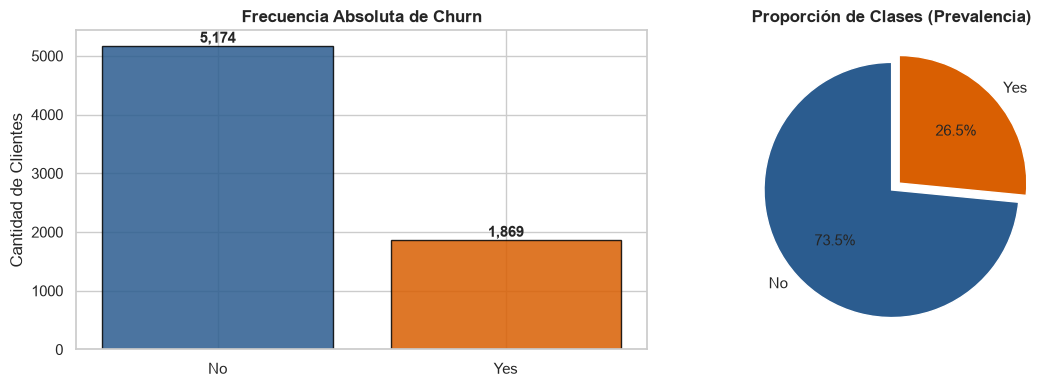

In [7]:
churn_counts = df["Churn"].value_counts()
churn_rates = df["Churn"].value_counts(normalize=True) * 100

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

colors = ["#2b5c8f", "#d95f02"]

ax[0].bar(
    churn_counts.index,
    churn_counts.values,
    color=colors,
    edgecolor="black",
    alpha=0.85
)

ax[0].set_title(
    "Frecuencia Absoluta de Churn",
    fontweight="bold"
)

ax[0].set_ylabel("Cantidad de Clientes")

for i, v in enumerate(churn_counts.values):
    ax[0].text(
        i,
        v + 50,
        f"{v:,}",
        ha="center",
        fontweight="bold"
    )

ax[1].pie(
    churn_rates.values,
    labels=churn_rates.index,
    autopct="%.1f%%",
    colors=colors,
    startangle=90,
    explode=(0, 0.08)
)

ax[1].set_title(
    "Proporción de Clases (Prevalencia)",
    fontweight="bold"
)

plt.tight_layout()
plt.show()

> **Lo que los datos muestran**
>
> El 26.54% de la base (1,869 clientes) presenta `Churn = Yes`, frente al 73.46% (5,174) con `Churn = No`. La clase positiva es minoritaria.
>
> **Lo que el grupo interpreta**
>
> Un clasificador que predijera siempre la clase mayoritaria podría obtener una Accuracy cercana a 73.5% y, al mismo tiempo, un Recall de 0 para churn. Por ello, Accuracy no será la única métrica: el proyecto prioriza PR-AUC y analiza también Recall, Precision, F1, ROC-AUC y matriz de confusión.

### 5. Pregunta 1: ¿Qué tipo de compromiso contractual presenta mayor tasa observada de fuga?

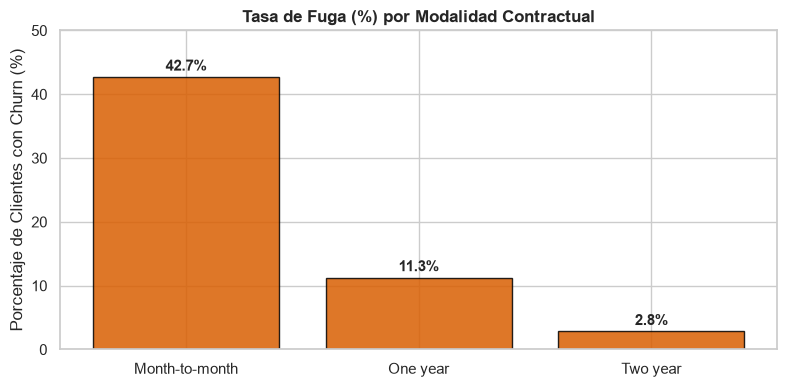

In [8]:
contract_churn = (
    df.groupby("Contract")["Churn_Binario"]
    .agg(["count", "mean"])
    .reset_index()
)

contract_churn["Tasa_Churn_%"] = (
    contract_churn["mean"] * 100
)

fig, ax = plt.subplots(figsize=(8, 4))

bars = ax.bar(
    contract_churn["Contract"],
    contract_churn["Tasa_Churn_%"],
    color="#d95f02",
    edgecolor="black",
    alpha=0.85
)

ax.set_title(
    "Tasa de Fuga (%) por Modalidad Contractual",
    fontweight="bold"
)

ax.set_ylabel(
    "Porcentaje de Clientes con Churn (%)"
)

ax.set_ylim(0, 50)

for bar in bars:
    yval = bar.get_height()

    ax.text(
        bar.get_x() + bar.get_width() / 2,
        yval + 1,
        f"{yval:.1f}%",
        ha="center",
        fontweight="bold"
    )

plt.tight_layout()
plt.show()

> **Lo que los datos muestran**
>
> Los contratos `Month-to-month` presentan una tasa observada de churn de **42.7%**, frente a **11.3%** en contratos de un año y **2.8%** en contratos de dos años.
>
> **Lo que el grupo interpreta**
>
> El tipo de contrato presenta una asociación fuerte con `Churn` dentro de esta muestra y constituye una variable relevante para el modelamiento. Este resultado puede orientar hipótesis de retención, pero el EDA por sí solo **no demuestra que cambiar el tipo de contrato cause una reducción del churn**.

### 6. Pregunta 2: ¿Existe una concentración de churn durante los primeros meses de antigüedad?

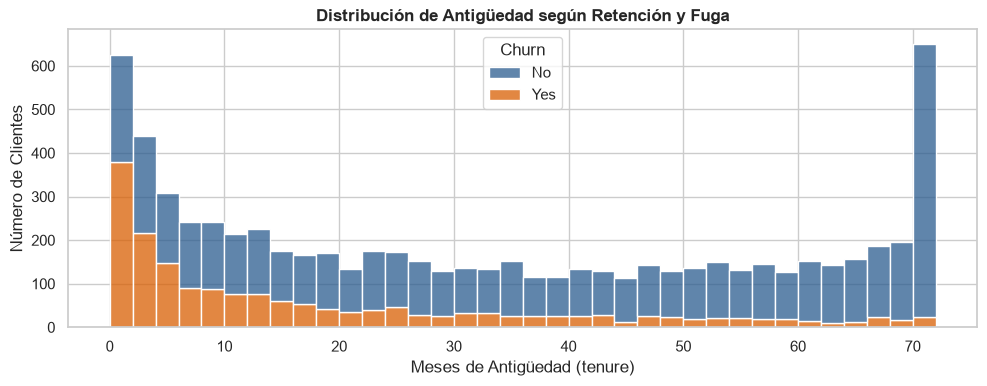

In [9]:
fig, ax = plt.subplots(figsize=(10, 4))

sns.histplot(
    data=df,
    x="tenure",
    hue="Churn",
    bins=36,
    multiple="stack",
    palette=["#2b5c8f", "#d95f02"],
    ax=ax
)

ax.set_title(
    "Distribución de Antigüedad según Retención y Fuga",
    fontweight="bold"
)

ax.set_xlabel("Meses de Antigüedad (tenure)")
ax.set_ylabel("Número de Clientes")

plt.tight_layout()
plt.show()

> **Lo que los datos muestran**
>
> La mayor concentración absoluta de casos de churn se observa durante los primeros meses de antigüedad, con especial presencia en los valores bajos de `tenure`.
>
> **Lo que el grupo interpreta**
>
> El patrón sugiere una etapa temprana de mayor riesgo que merece análisis posterior. El dataset no permite determinar la causa de esa asociación.
>
> Como referencia exploratoria, el proyecto utiliza una regla heurística basada en `Month-to-month` y `tenure <= 6`. Debido a que esta regla fue inspirada por el EDA, se interpreta como **baseline descriptivo** y no como una evaluación completamente ciega. La selección entre los modelos de Machine Learning se realiza por separado usando Validation.

### 7. Pregunta 3: ¿Cómo se relacionan los cargos mensuales y el soporte técnico con churn?

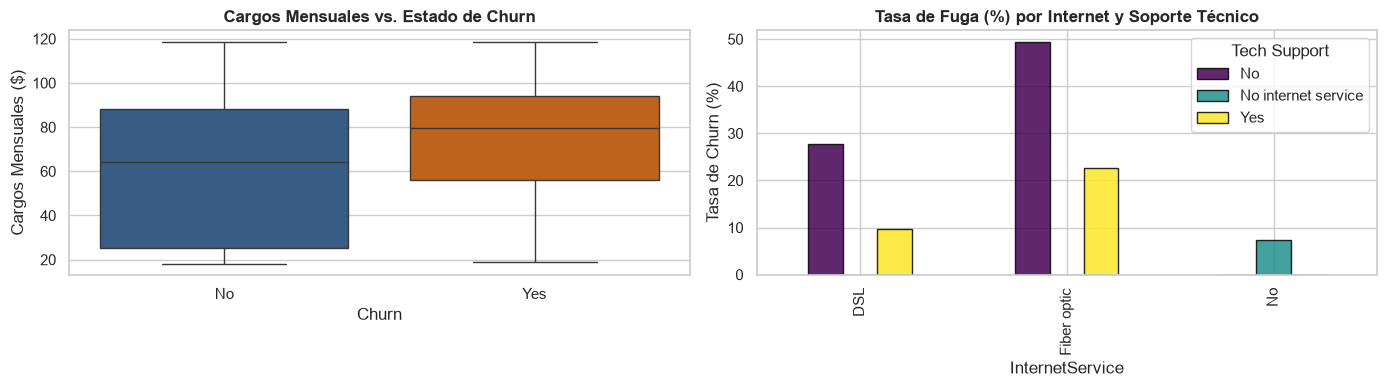

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4))

sns.boxplot(
    data=df,
    x="Churn",
    y="MonthlyCharges",
    palette=["#2b5c8f", "#d95f02"],
    ax=ax[0]
)

ax[0].set_title(
    "Cargos Mensuales vs. Estado de Churn",
    fontweight="bold"
)

ax[0].set_ylabel("Cargos Mensuales ($)")

support_summary = (
    df.groupby(
        ["InternetService", "TechSupport"]
    )["Churn_Binario"]
    .mean()
    .unstack()
    * 100
)

support_summary.plot(
    kind="bar",
    ax=ax[1],
    colormap="viridis",
    edgecolor="black",
    alpha=0.85
)

ax[1].set_title(
    "Tasa de Fuga (%) por Internet y Soporte Técnico",
    fontweight="bold"
)

ax[1].set_ylabel("Tasa de Churn (%)")
ax[1].legend(title="Tech Support")

plt.tight_layout()
plt.show()

> **Lo que los datos muestran**
>
> 1. Los clientes con `Churn = Yes` presentan cargos mensuales más altos en la distribución observada.
> 2. Dentro de la muestra, los clientes con `Fiber optic` y `TechSupport = No` presentan una tasa de churn cercana al **49.4%**, mientras que el grupo con soporte técnico presenta una tasa considerablemente menor.
>
> **Lo que el grupo interpreta**
>
> La combinación entre tipo de internet, cargo mensual y soporte técnico constituye un segmento de interés para el análisis. Sin embargo, estos datos muestran **asociaciones** y no permiten afirmar que la ausencia de soporte sea la causa de la cancelación. Esa relación puede plantearse como hipótesis para análisis futuro.

### 8. Pregunta 4: ¿Cómo se relaciona el método de pago con la tasa observada de churn?

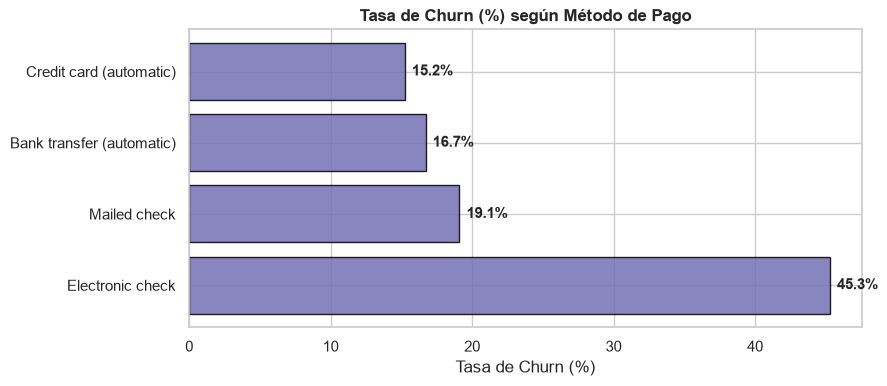

In [11]:
pay_churn = (
    df.groupby("PaymentMethod")["Churn_Binario"]
    .mean()
    .sort_values(ascending=False)
    * 100
)

fig, ax = plt.subplots(figsize=(9, 4))

bars = ax.barh(
    pay_churn.index,
    pay_churn.values,
    color="#7570b3",
    edgecolor="black",
    alpha=0.85
)

ax.set_title(
    "Tasa de Churn (%) según Método de Pago",
    fontweight="bold"
)

ax.set_xlabel("Tasa de Churn (%)")

for bar in bars:
    wval = bar.get_width()

    ax.text(
        wval + 0.5,
        bar.get_y() + bar.get_height() / 2,
        f"{wval:.1f}%",
        va="center",
        fontweight="bold"
    )

plt.tight_layout()
plt.show()

> **Lo que los datos muestran**
>
> `Electronic check` presenta una tasa observada de churn cercana al **45.3%**, mayor que la observada en los métodos de pago automático.
>
> **Lo que el grupo interpreta**
>
> El método de pago está asociado con diferentes niveles de churn en la muestra y puede aportar señal predictiva. El EDA no permite concluir que el mecanismo de pago sea la causa de la cancelación; podrían existir otras características del cliente relacionadas con ambos fenómenos.

### 9. Síntesis del EDA y decisiones que condicionan el preprocesamiento

A partir de la evidencia observada:

1. **Identificador:** `customerID` se excluye del modelamiento por ser un identificador y no una característica predictiva de negocio.
2. **`TotalCharges`:** se convierte a numérico y los 11 casos con `tenure = 0` se representan con `TotalCharges = 0` mediante una regla lógica explícita.
3. **Variables numéricas:** `tenure`, `MonthlyCharges` y `TotalCharges` se procesan mediante un pipeline con imputación de respaldo y `StandardScaler`.
4. **Variables categóricas:** se utiliza `OneHotEncoder` para evitar imponer un orden artificial y mantener un flujo reproducible.
5. **Valores extremos:** se investigan antes de tomar decisiones; no se eliminan automáticamente por aparecer fuera del rango IQR.
6. **Asociación ≠ causalidad:** los patrones de contrato, antigüedad, soporte y método de pago se utilizan como evidencia exploratoria e hipótesis, no como relaciones causales demostradas.
7. **Estrategia de partición del modelamiento:** el Notebook 02 utiliza una separación estratificada **70% Train / 15% Validation / 15% Test**, con `random_state=42`.
   - **Train:** ajuste del preprocesamiento y entrenamiento.
   - **Validation:** comparación de Regresión Logística y Random Forest y selección preliminar mediante PR-AUC.
   - **Test:** evaluación final después de seleccionar el candidato.
8. **Prevención de leakage:** imputación estadística, escalado y categorías del `OneHotEncoder` se aprenden dentro del `Pipeline` usando únicamente los datos destinados al entrenamiento en cada etapa. Test no interviene en la selección del modelo.

> **Nota metodológica sobre el EDA:** este cuaderno es descriptivo y utiliza el dataset para comprender patrones. La regla heurística inspirada por este EDA se mantiene solo como baseline exploratorio; la selección del modelo supervisado se realiza en Validation y Test queda reservado para la evaluación final.